# FedSenseFormer-UQ
## FedSenseFormer-UQ: Conformal Uncertainty Quantification and Horizon Limits in Personalized Federated Vital-Sign Forecasting from Wearable Physiological Sensors

**Q1-journal extension of:** *AI-Driven IoT Framework for Predictive Healthcare Monitoring Using Wearable Sensors* (Springer LNNS, 2026)

### Main contributions implemented in this notebook
1. Real physiological validation on the **PhysioNet BIDMC PPG and Respiration Dataset**.
2. Multimodal ECG–PPG–respiration feature fusion with HR/RR/SpO₂.
3. Multi-task **future vital-sign forecasting** instead of only current-state classification.
4. Proposed **FedSenseFormer-UQ** temporal Transformer.
5. Subject-wise, leakage-resistant train/validation/test protocol.
6. Personalized **federated learning (FedAvg)** simulation.
7. Predictive uncertainty using **Monte-Carlo dropout + split conformal calibration**.
8. Explainability through **sensor-group occlusion importance**.
9. Classical and deep-learning baselines.
10. Ablation study, statistical significance, bootstrap confidence intervals, model-size and latency analysis.

> **Important:** This notebook does not hard-code or fabricate research results. All tables and figures are generated from the actual run.

## Research question and prediction task

For every patient, the input is a rolling history window of multimodal physiological observations.  
The model predicts the patient's **future heart rate (HR), respiratory rate (RR), and SpO₂** at a configurable forecasting horizon.

Default configuration:
- input history = 60 s
- forecast horizon = 30 s
- stride = 5 s

This converts wearable monitoring from *recognition* into **proactive physiological forecasting**, which is a stronger journal-level extension.

In [1]:
# ============================================================
# 1. COLAB SETUP
# ============================================================
!pip -q install numpy pandas scipy scikit-learn matplotlib tqdm requests

try:
    import torch
    print("Using Colab's preinstalled torch:", torch.__version__)
except ImportError:
    !pip -q install torch
    import torch

import os, re, math, time, random, warnings, copy, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from scipy.stats import wilcoxon, chi2

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Using Colab's preinstalled torch: 2.11.0+cu128
Device: cuda


In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================
QUICK_RUN = False     # MUST be False for the reviewer-required full-scale run

# Target reformulation (Reviewer Comment #1): predict the RESIDUAL change
# in each vital (y[t+horizon] - y[t]) instead of its absolute value. All
# predictions are reconstructed back to absolute clinical units via each
# window's "anchor" (last observed vital at t) before ANY metric is
# computed, so results stay comparable to the persistence baseline.
DELTA_TARGET = True

DOWNLOAD_RAW_SIGNALS = True

DATA_DIR = Path("/content/bidmc_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

N_SUBJECTS = 16 if QUICK_RUN else 53
HISTORY_SEC = 60
STRIDE_SEC = 5

# ============================================================
# MULTI-HORIZON EXTENSION (Reviewer suggestion: test whether persistence
# dominance collapses at longer horizons, as the wider forecasting
# literature reports for comparable ICU tasks). HORIZON_SEC is no longer
# a fixed constant -- it is set fresh inside the outer loop in the driver
# cell below, once per horizon in HORIZONS_TO_RUN, immediately before
# subject_windows is rebuilt for that horizon. Nothing before the driver
# cell should read HORIZON_SEC; it is initialized here only so any
# diagnostic print before the driver runs has a defined value to show.
# ============================================================
HORIZONS_TO_RUN = [30, 60, 120, 300]   # seconds ahead
HORIZON_SEC = HORIZONS_TO_RUN[0]

BATCH_SIZE = 128 if torch.cuda.is_available() else 64
EPOCHS = 12 if QUICK_RUN else 40
PATIENCE = 4 if QUICK_RUN else 8
LR = 1e-3

FED_ROUNDS = 3 if QUICK_RUN else 12
FED_CLIENTS_PER_ROUND = 5 if QUICK_RUN else 12
FED_LOCAL_EPOCHS = 1 if QUICK_RUN else 2

MC_SAMPLES = 12 if QUICK_RUN else 40

# Reviewer Comments #3 and #4: widened calibration/test subject partitions.
VAL_FRACTION = 0.20   # was 0.15
TEST_FRACTION = 0.25  # was 0.20

# ============================================================
# AUTOMATED 5-SEED x 4-HORIZON DRIVER
# Run this notebook top-to-bottom ONCE; the driver cell near the end
# loops over every (horizon, seed) pair below in a single long-lived
# runtime -- 4 horizons x 5 seeds = 20 total runs -- skipping any run
# whose output folder already exists (safe to re-run after a disconnect).
# ============================================================
SEEDS_TO_RUN = [42, 43, 44, 45, 46]

print({
    "QUICK_RUN": QUICK_RUN,
    "DELTA_TARGET": DELTA_TARGET,
    "HORIZONS_TO_RUN": HORIZONS_TO_RUN,
    "SEEDS_TO_RUN": SEEDS_TO_RUN,
    "total_runs": len(HORIZONS_TO_RUN) * len(SEEDS_TO_RUN),
    "subjects": N_SUBJECTS,
    "val_fraction": VAL_FRACTION,
    "test_fraction": TEST_FRACTION,
    "history_sec": HISTORY_SEC,
    "device": str(DEVICE)
})


{'QUICK_RUN': False, 'DELTA_TARGET': True, 'HORIZONS_TO_RUN': [30, 60, 120, 300], 'SEEDS_TO_RUN': [42, 43, 44, 45, 46], 'total_runs': 20, 'subjects': 53, 'val_fraction': 0.2, 'test_fraction': 0.25, 'history_sec': 60, 'device': 'cuda'}


## Dataset

The notebook directly downloads the open **BIDMC PPG and Respiration Dataset** from PhysioNet.  
Each record includes high-frequency physiological signals and 1-Hz monitor numerics.

To keep training efficient while preserving multimodal information, raw 125-Hz waveforms are summarized into robust **1-second sensor descriptors** (mean, standard deviation, RMS, range and slope). These descriptors are merged with HR, pulse, respiration rate and SpO₂ numerics.

In [3]:
# ============================================================
# 3. DOWNLOAD BIDMC CSV FILES DIRECTLY FROM PHYSIONET
# ============================================================
import requests

BASE = "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"

def download_file(url, path):
    if path.exists():
        return
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    path.write_bytes(r.content)

subjects = [f"{i:02d}" for i in range(1, N_SUBJECTS + 1)]

for sid in tqdm(subjects, desc="Downloading BIDMC"):
    num_name = f"bidmc_{sid}_Numerics.csv"
    download_file(f"{BASE}/{num_name}", DATA_DIR / num_name)

    if DOWNLOAD_RAW_SIGNALS:
        sig_name = f"bidmc_{sid}_Signals.csv"
        download_file(f"{BASE}/{sig_name}", DATA_DIR / sig_name)

print("Downloaded files:", len(list(DATA_DIR.glob("*"))))

Downloaded files: 106


In [4]:
# ============================================================
# 4. INSPECT ONE SUBJECT
# ============================================================
sid = subjects[0]
num = pd.read_csv(DATA_DIR / f"bidmc_{sid}_Numerics.csv")
print("Numerics columns:", list(num.columns))
display(num.head())

if DOWNLOAD_RAW_SIGNALS:
    sig = pd.read_csv(DATA_DIR / f"bidmc_{sid}_Signals.csv")
    print("Signal columns:", list(sig.columns))
    display(sig.head())

Numerics columns: ['Time [s]', ' HR', ' PULSE', ' RESP', ' SpO2']


,Time [s],HR,PULSE,RESP,SpO2
0,0,94,93.0,25,97.0
1,1,94,93.0,25,97.0
2,2,94,93.0,25,97.0
3,3,92,93.0,26,97.0
4,4,93,93.0,26,97.0


Signal columns: ['Time [s]', ' RESP', ' PLETH', ' V', ' AVR', ' II']


,Time [s],RESP,PLETH,V,AVR,II
0,0.000,0.35386,0.43597,0.52549,0.30392,0.72549
1,0.008,0.35679,0.43206,0.51961,0.33529,0.67059
2,0.016,0.35875,0.42815,0.51569,0.37451,0.60980
3,0.024,0.36168,0.42424,0.50588,0.41961,0.55098
4,0.032,0.36364,0.42131,0.50980,0.44902,0.50000


In [5]:
# ============================================================
# 5. ROBUST COLUMN UTILITIES
# ============================================================
def normalize_col(c):
    return re.sub(r"[^a-z0-9]+", "", c.lower())

def find_col(df, candidates):
    norm = {normalize_col(c): c for c in df.columns}
    for cand in candidates:
        nc = normalize_col(cand)
        if nc in norm:
            return norm[nc]
    # partial fallback
    for c in df.columns:
        nc = normalize_col(c)
        for cand in candidates:
            if normalize_col(cand) in nc:
                return c
    return None

def numeric_clean(s):
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

In [6]:
# ============================================================
# 6. BUILD 1-HZ MULTIMODAL FEATURE TABLE FOR EACH SUBJECT
# ============================================================
def waveform_1s_features(sig_df, fs=125):
    tcol = find_col(sig_df, ["Time [s]", "Time", "Seconds"])
    if tcol is None:
        t = np.arange(len(sig_df)) / fs
    else:
        t = numeric_clean(sig_df[tcol]).values

    work = pd.DataFrame({"sec": np.floor(t).astype(int)})

    candidate_groups = {
        "ecg": ["II", "ECG", "Lead II"],
        "ppg": ["PLETH", "PPG"],
        "resp_wave": ["RESP", "Respiration"]
    }

    selected = {}
    for group, cands in candidate_groups.items():
        col = find_col(sig_df, cands)
        if col is not None:
            selected[group] = col
            work[group] = numeric_clean(sig_df[col]).values

    feats = []
    for sec, g in work.groupby("sec"):
        row = {"sec": sec}
        for group in selected:
            x = g[group].dropna().values.astype(float)
            if len(x) == 0:
                for stat in ["mean","std","rms","range","slope"]:
                    row[f"{group}_{stat}"] = np.nan
                continue
            row[f"{group}_mean"] = np.mean(x)
            row[f"{group}_std"] = np.std(x)
            row[f"{group}_rms"] = np.sqrt(np.mean(x**2))
            row[f"{group}_range"] = np.ptp(x)
            row[f"{group}_slope"] = np.polyfit(np.arange(len(x)), x, 1)[0] if len(x) > 2 else 0.0
        feats.append(row)
    return pd.DataFrame(feats)

def load_subject_table(sid):
    num = pd.read_csv(DATA_DIR / f"bidmc_{sid}_Numerics.csv")
    tcol = find_col(num, ["Time [s]", "Time", "Seconds"])
    if tcol is None:
        num["sec"] = np.arange(len(num))
    else:
        num["sec"] = np.round(numeric_clean(num[tcol])).astype("Int64")

    hr = find_col(num, ["HR", "Heart Rate"])
    pulse = find_col(num, ["PULSE", "Pulse Rate", "PR"])
    rr = find_col(num, ["RESP", "Respiratory Rate", "RR"])
    spo2 = find_col(num, ["SpO2", "Oxygen Saturation"])

    out = pd.DataFrame({"sec": num["sec"]})
    mapping = {"hr": hr, "pulse": pulse, "rr": rr, "spo2": spo2}
    for new, old in mapping.items():
        out[new] = numeric_clean(num[old]) if old is not None else np.nan

    if DOWNLOAD_RAW_SIGNALS:
        sig = pd.read_csv(DATA_DIR / f"bidmc_{sid}_Signals.csv")
        wf = waveform_1s_features(sig)
        out = out.merge(wf, on="sec", how="left")

    out = out.sort_values("sec").reset_index(drop=True)
    out["subject"] = sid

    # physiologically impossible monitor artifacts -> missing
    bounds = {
        "hr": (20, 240),
        "pulse": (20, 240),
        "rr": (2, 80),
        "spo2": (50, 100)
    }
    for c, (lo, hi) in bounds.items():
        if c in out:
            out.loc[~out[c].between(lo, hi), c] = np.nan

    # short-gap interpolation only, then edge fill
    feature_cols = [c for c in out.columns if c not in ["sec","subject"]]
    out[feature_cols] = out[feature_cols].interpolate(limit=5, limit_direction="both")
    out[feature_cols] = out[feature_cols].ffill().bfill()
    return out

tables = {}
for sid in tqdm(subjects, desc="Preprocessing subjects"):
    try:
        tables[sid] = load_subject_table(sid)
    except Exception as e:
        print("Skipping", sid, "because:", e)

print("Usable subjects:", len(tables))
display(next(iter(tables.values())).head())

Preprocessing subjects:   0%|          | 0/53 [00:00<?, ?it/s]

Usable subjects: 53


,sec,hr,pulse,rr,spo2,ecg_mean,ecg_std,ecg_rms,ecg_range,ecg_slope,...,ppg_std,ppg_rms,ppg_range,ppg_slope,resp_wave_mean,resp_wave_std,resp_wave_rms,resp_wave_range,resp_wave_slope,subject
0,0,94.0,93.0,25.0,97.0,0.442760,0.200443,0.486019,1.20978,-0.001008,...,0.065743,0.473226,0.19844,0.000180,0.218377,0.143119,0.261097,0.517107,0.000175,01
1,1,94.0,93.0,25.0,97.0,0.485959,0.263234,0.552674,1.27449,0.000092,...,0.060580,0.472257,0.18378,-0.000397,0.812489,0.196720,0.835964,0.532750,-0.002313,01
2,2,94.0,93.0,25.0,97.0,0.474149,0.238952,0.530957,1.23527,0.001097,...,0.074433,0.488086,0.20528,0.000387,0.206194,0.123509,0.240354,0.445750,-0.003284,01
3,3,92.0,93.0,26.0,97.0,0.452140,0.217187,0.501598,1.24900,0.000722,...,0.056665,0.453300,0.19844,-0.000061,0.745274,0.279974,0.796128,0.861190,0.006957,01
4,4,93.0,93.0,26.0,97.0,0.476063,0.236986,0.531788,1.23919,0.000613,...,0.074619,0.488315,0.24242,0.000793,0.307246,0.140133,0.337694,0.695989,-0.003262,01


,count,mean,std,min,25%,50%,75%,max,missing_%
hr,25493.0,89.181,13.326,44.0,81.0,89.0,95.0,139.0,0.0
rr,25493.0,17.522,3.214,2.0,16.0,18.0,19.0,34.0,0.0
spo2,25493.0,96.736,3.300,83.0,95.0,98.0,99.0,100.0,0.0


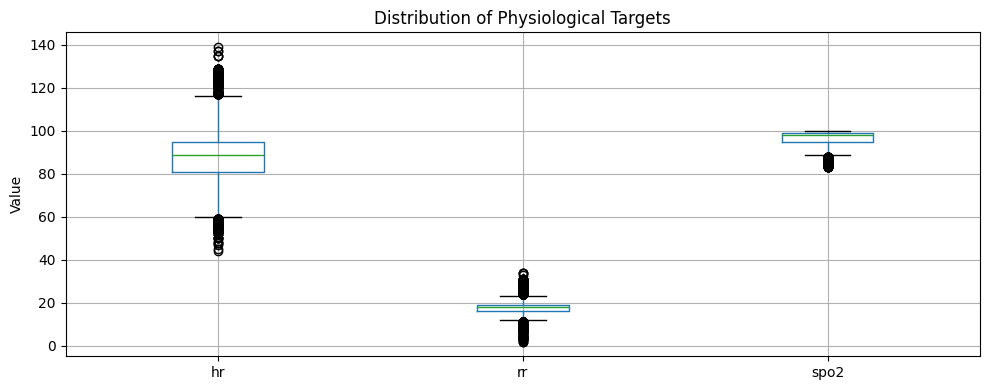

In [7]:
# ============================================================
# 7. DATA QUALITY / DESCRIPTIVE STATISTICS
# ============================================================
all_rows = pd.concat(tables.values(), ignore_index=True)

target_cols = ["hr", "rr", "spo2"]
desc = all_rows[target_cols].describe().T
desc["missing_%"] = all_rows[target_cols].isna().mean() * 100
display(desc.round(3))

fig = plt.figure(figsize=(10,4))
all_rows[target_cols].boxplot()
plt.title("Distribution of Physiological Targets")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 8. SUBJECT-WISE SEQUENCE WINDOW BUILDER (callable per horizon)
# ============================================================
# This cell now only DEFINES the builder; it does not build
# subject_windows itself. subject_windows is (re)built once per horizon,
# inside the outer loop in the driver cell, by calling
# build_subject_windows(horizon) -- because the window/target
# construction depends on HORIZON_SEC and must be redone for each of the
# 4 horizons in HORIZONS_TO_RUN before that horizon's 5 seeds are run.
EXCLUDE = {"sec", "subject"}
TARGETS = ["hr", "rr", "spo2"]
FEATURES = [c for c in next(iter(tables.values())).columns if c not in EXCLUDE]
print("Features:", FEATURES)
print("Targets:", TARGETS)

def make_windows(df, history, horizon, stride):
    """
    Returns, per window:
      X       -- (history, n_features) input sequence
      y       -- training target: RESIDUAL (y_abs - anchor) if
                 DELTA_TARGET else the absolute value itself
      y_abs   -- the absolute target value (always kept, for evaluation)
      anchor  -- the last-observed absolute vital at the end of the
                 input window (t), i.e. the persistence forecast;
                 used to reconstruct any model's prediction back to
                 absolute clinical units regardless of DELTA_TARGET
      t       -- the target timestamp in seconds
    """
    X, y, y_abs, anchor, t = [], [], [], [], []
    arr = df[FEATURES].values.astype(np.float32)
    tar = df[TARGETS].values.astype(np.float32)

    max_i = len(df) - horizon
    for end in range(history, max_i, stride):
        start = end - history
        target_idx = end + horizon - 1
        xw = arr[start:end]
        yw_abs = tar[target_idx]
        anchor_w = tar[end - 1]
        yw = (yw_abs - anchor_w) if DELTA_TARGET else yw_abs
        if np.isfinite(xw).all() and np.isfinite(yw_abs).all() and np.isfinite(anchor_w).all():
            X.append(xw)
            y.append(yw)
            y_abs.append(yw_abs)
            anchor.append(anchor_w)
            t.append(int(df.iloc[target_idx]["sec"]))
    return (np.array(X, dtype=np.float32), np.array(y, dtype=np.float32),
            np.array(y_abs, dtype=np.float32), np.array(anchor, dtype=np.float32),
            np.array(t))

def build_subject_windows(horizon):
    """Rebuilds the full subject_windows dict for one specific horizon."""
    sw = {}
    for sid, df in tables.items():
        Xs, ys, ys_abs, anchors, ts = make_windows(df, HISTORY_SEC, horizon, STRIDE_SEC)
        if len(Xs) >= 10:
            sw[sid] = (Xs, ys, ys_abs, anchors, ts)
    return sw

print("build_subject_windows(horizon) defined -- called once per horizon in the driver cell.")


Features: ['hr', 'pulse', 'rr', 'spo2', 'ecg_mean', 'ecg_std', 'ecg_rms', 'ecg_range', 'ecg_slope', 'ppg_mean', 'ppg_std', 'ppg_rms', 'ppg_range', 'ppg_slope', 'resp_wave_mean', 'resp_wave_std', 'resp_wave_rms', 'resp_wave_range', 'resp_wave_slope']
Targets: ['hr', 'rr', 'spo2']
build_subject_windows(horizon) defined -- called once per horizon in the driver cell.


In [9]:
# ============================================================
# ONE-TIME DEFINITIONS (models, metrics, training helpers)
# Runs once. None of this depends on the seed -- only weight
# INITIALIZATION does, and that happens fresh inside run_one_seed()
# every time a model class is instantiated there.
# ============================================================

# ---- 11. Evaluation helpers ----
def evaluate_multitask(y_true, y_pred, model_name):
    rows = []
    for j, target in enumerate(TARGETS):
        yt, yp = y_true[:, j], y_pred[:, j]
        rows.append({
            "Model": model_name,
            "Target": target.upper(),
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": mean_squared_error(yt, yp) ** 0.5,
            "R2": r2_score(yt, yp)
        })
    macro = {
        "Model": model_name,
        "Target": "MACRO",
        "MAE": np.mean([r["MAE"] for r in rows]),
        "RMSE": np.mean([r["RMSE"] for r in rows]),
        "R2": np.mean([r["R2"] for r in rows])
    }
    return pd.DataFrame(rows + [macro])

def subject_mae(y_true, y_pred, subjects_arr):
    vals = {}
    for sid in np.unique(subjects_arr):
        m = subjects_arr == sid
        vals[sid] = np.mean(np.abs(y_true[m] - y_pred[m]))
    return vals

# ---- 13. Tabular sequence summarization (for Ridge / ExtraTrees) ----
def summarize_sequences(X):
    mean = X.mean(axis=1)
    std = X.std(axis=1)
    mn = X.min(axis=1)
    mx = X.max(axis=1)
    last = X[:, -1, :]
    slope = (X[:, -1, :] - X[:, 0, :]) / max(1, X.shape[1]-1)
    return np.concatenate([mean, std, mn, mx, last, slope], axis=1)

# ---- 17. Model definitions ----
class BiLSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden*2, 3)
    def forward(self, x):
        z, _ = self.lstm(x)
        return self.head(self.dropout(z[:, -1]))

class TCNRegressor(nn.Module):
    def __init__(self, n_features, hidden=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, hidden, 5, padding=2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden, 5, padding=4, dilation=2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden, 5, padding=8, dilation=4),
            nn.GELU()
        )
        self.head = nn.Linear(hidden, 3)
    def forward(self, x):
        z = self.net(x.transpose(1,2))
        return self.head(z[:, :, -1])

class TransformerRegressor(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, layers=2, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        self.pos = nn.Parameter(torch.randn(1, HISTORY_SEC, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 3)
    def forward(self, x):
        z = self.proj(x) + self.pos[:, :x.size(1)]
        z = self.encoder(z)
        z = z.mean(dim=1)
        return self.head(self.dropout(z))

class FedSenseFormer(nn.Module):
    """
    Proposed model: gated input calibration + local temporal convolution +
    Transformer global context + residual statistics fusion.
    Dropout remains active for MC-dropout uncertainty.
    """
    def __init__(self, n_features, d_model=80, nhead=4, layers=3, dropout=0.25):
        super().__init__()
        self.input_gate = nn.Sequential(nn.Linear(n_features, n_features), nn.Sigmoid())
        self.local = nn.Sequential(
            nn.Conv1d(n_features, d_model, kernel_size=5, padding=2),
            nn.GELU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.GELU()
        )
        self.pos = nn.Parameter(torch.randn(1, HISTORY_SEC, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=layers)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.stat_proj = nn.Linear(n_features*2, d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model*2, 96), nn.GELU(), nn.Dropout(dropout), nn.Linear(96, 3)
        )
    def forward(self, x):
        gate = self.input_gate(x.mean(dim=1)).unsqueeze(1)
        xg = x * gate
        local = self.local(xg.transpose(1,2)).transpose(1,2)
        z = local + self.pos[:, :x.size(1)]
        z = self.encoder(z)
        z = self.norm(z.mean(dim=1))
        stats = torch.cat([xg.mean(dim=1), xg.std(dim=1)], dim=-1)
        stats = self.stat_proj(stats)
        fused = torch.cat([z, stats], dim=-1)
        return self.head(self.dropout(fused))

class AblatedFedSenseFormer(FedSenseFormer):
    def __init__(self, n_features, no_gate=False, no_stats=False, **kwargs):
        super().__init__(n_features, **kwargs)
        self.no_gate = no_gate
        self.no_stats = no_stats
    def forward(self, x):
        if self.no_gate:
            xg = x
        else:
            gate = self.input_gate(x.mean(dim=1)).unsqueeze(1)
            xg = x * gate
        local = self.local(xg.transpose(1,2)).transpose(1,2)
        z = local + self.pos[:, :x.size(1)]
        z = self.encoder(z)
        z = self.norm(z.mean(dim=1))
        if self.no_stats:
            stats = torch.zeros_like(z)
        else:
            stats = torch.cat([xg.mean(dim=1), xg.std(dim=1)], dim=-1)
            stats = self.stat_proj(stats)
        return self.head(self.dropout(torch.cat([z, stats], dim=-1)))

# ---- 18. Train / predict helpers ----
def train_model(model, train_loader, val_loader, epochs, lr, patience, device):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()
    best_state, best_val, bad = None, float("inf"), 0
    history = []
    for epoch in range(1, epochs+1):
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_losses.append(loss.item())
        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_losses.append(loss_fn(model(xb), yb).item())
        tr, va = np.mean(tr_losses), np.mean(va_losses)
        history.append((epoch, tr, va))
        if va < best_val - 1e-5:
            best_val = va
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history, columns=["epoch","train_loss","val_loss"])

@torch.no_grad()
def predict_scaled(model, loader, device):
    model.eval()
    out = []
    for xb, _ in loader:
        out.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(out)

def enable_mc_dropout(model):
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

def fedavg(state_dicts, weights):
    total = float(sum(weights))
    out = copy.deepcopy(state_dicts[0])
    for k in out:
        out[k] = sum(sd[k].float() * (w/total) for sd, w in zip(state_dicts, weights))
    return out

def local_train_from_global(global_model, dataset, epochs, lr, batch_size, device):
    local = copy.deepcopy(global_model).to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    opt = torch.optim.AdamW(local.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()
    local.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(local(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(local.parameters(), 1.0)
            opt.step()
    return {k:v.detach().cpu() for k,v in local.state_dict().items()}

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

print("One-time definitions loaded: models, training helpers, evaluation helpers.")


One-time definitions loaded: models, training helpers, evaluation helpers.


In [10]:
# ============================================================
# PER-SEED PIPELINE (replaces the old cells 9-36; everything that
# depends on the random seed lives here, as one callable function).
# Called once per seed by the driver cell below. Fully local
# variables -- nothing here leaks into the next seed's run.
# ============================================================
def run_one_seed(seed, horizon, force_rerun=False):
    run_tag = f"h{horizon}_seed{seed}"
    out_dir = Path(f"/content/fedsenseformer_outputs_{run_tag}")

    # Resumability: skip seeds already completed AT THE CORRECT SCALE (e.g.
    # by hand before switching to this automated driver, or in an earlier
    # call to this driver that was interrupted). A folder from an old
    # QUICK_RUN=True pilot run does NOT count as complete here -- it is
    # detected and re-run, so a stale pilot-scale folder can never be
    # silently mistaken for a finished full-scale run.
    cfg_path = out_dir / "run_config.csv"
    if out_dir.exists() and cfg_path.exists() and not force_rerun:
        prior_cfg = pd.read_csv(cfg_path).iloc[0]
        if bool(prior_cfg.get("QUICK_RUN", True)) == QUICK_RUN and \
           bool(prior_cfg.get("DELTA_TARGET", None)) == DELTA_TARGET:
            print(f"[h={horizon}s seed={seed}] output already exists at {out_dir} "
                  f"(QUICK_RUN={prior_cfg['QUICK_RUN']}, matches current config) "
                  f"-- skipping (pass force_rerun=True to redo it).")
            return out_dir
        else:
            print(f"[h={horizon}s seed={seed}] existing folder found but was run with "
                  f"QUICK_RUN={prior_cfg.get('QUICK_RUN')} (current: {QUICK_RUN}) -- "
                  f"treating as stale and RE-RUNNING at the current configuration.")

    print(f"\n{'='*60}\n[h={horizon}s seed={seed}] starting full-scale run\n{'='*60}")
    t_seed_start = time.time()
    out_dir.mkdir(parents=True, exist_ok=True)

    # ---- re-seed everything for this run ----
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    all_results = []
    prediction_store = {}

    # ---- 9. Subject-independent split ----
    valid_subjects = sorted(subject_windows.keys())
    rng = np.random.default_rng(seed)
    rng.shuffle(valid_subjects)
    n = len(valid_subjects)
    n_test = max(2, round(TEST_FRACTION * n))
    n_val = max(2, round(VAL_FRACTION * n))
    test_subjects = valid_subjects[:n_test]
    val_subjects = valid_subjects[n_test:n_test+n_val]
    train_subjects = valid_subjects[n_test+n_val:]

    def stack_subjects(sids):
        X = np.concatenate([subject_windows[s][0] for s in sids], axis=0)
        y = np.concatenate([subject_windows[s][1] for s in sids], axis=0)
        y_abs = np.concatenate([subject_windows[s][2] for s in sids], axis=0)
        anchor = np.concatenate([subject_windows[s][3] for s in sids], axis=0)
        subj = np.concatenate([[s]*len(subject_windows[s][0]) for s in sids])
        return X, y, y_abs, anchor, subj

    X_train, y_train, y_train_abs, anchor_train, s_train = stack_subjects(train_subjects)
    X_val, y_val, y_val_abs, anchor_val, s_val = stack_subjects(val_subjects)
    X_test, y_test, y_test_abs, anchor_test, s_test = stack_subjects(test_subjects)
    print(f"[h={horizon}s seed={seed}] train/val/test subjects: "
          f"{len(train_subjects)}/{len(val_subjects)}/{len(test_subjects)}, "
          f"windows: {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")

    # ---- 10. Train-only standardization ----
    n_features = X_train.shape[-1]
    x_scaler = StandardScaler().fit(X_train.reshape(-1, n_features))
    y_scaler = StandardScaler().fit(y_train)
    def scale_X(X):
        shape = X.shape
        return x_scaler.transform(X.reshape(-1, shape[-1])).reshape(shape).astype(np.float32)
    def scale_y(y):
        return y_scaler.transform(y).astype(np.float32)
    Xs_train, Xs_val, Xs_test = map(scale_X, [X_train, X_val, X_test])
    ys_train, ys_val, ys_test = map(scale_y, [y_train, y_val, y_test])

    train_loader = DataLoader(SeqDataset(Xs_train, ys_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(SeqDataset(Xs_val, ys_val), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(SeqDataset(Xs_test, ys_test), batch_size=BATCH_SIZE, shuffle=False)

    def fit_and_eval(name, model):
        t0 = time.time()
        model, hist = train_model(model, train_loader, val_loader, EPOCHS, LR, PATIENCE, DEVICE)
        train_time = time.time() - t0
        pred = y_scaler.inverse_transform(predict_scaled(model, test_loader, DEVICE))
        if DELTA_TARGET:
            pred = pred + anchor_test
        res = evaluate_multitask(y_test_abs, pred, name)
        res["TrainSeconds"] = train_time
        all_results.append(res)
        prediction_store[name] = pred
        return model, hist, res

    # ---- 12. Baseline 1: Persistence ----
    feature_index = {c:i for i,c in enumerate(FEATURES)}
    last_cols = [feature_index[t] for t in TARGETS]
    pred_persistence = X_test[:, -1, last_cols]
    res = evaluate_multitask(y_test_abs, pred_persistence, "Persistence")
    all_results.append(res)
    prediction_store["Persistence"] = pred_persistence

    # ---- 13. Tabular summarization + Baseline 2/3: Ridge, ExtraTrees ----
    E_train, E_val, E_test = map(summarize_sequences, [Xs_train, Xs_val, Xs_test])

    ridge = Ridge(alpha=2.0)
    ridge.fit(E_train, ys_train)
    pred = y_scaler.inverse_transform(ridge.predict(E_test))
    if DELTA_TARGET: pred = pred + anchor_test
    all_results.append(evaluate_multitask(y_test_abs, pred, "Ridge"))
    prediction_store["Ridge"] = pred

    et = ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.8,
                              n_jobs=-1, random_state=seed)
    et.fit(E_train, ys_train)
    pred = y_scaler.inverse_transform(et.predict(E_test))
    if DELTA_TARGET: pred = pred + anchor_test
    all_results.append(evaluate_multitask(y_test_abs, pred, "ExtraTrees"))
    prediction_store["ExtraTrees"] = pred

    # ---- 19-22. Baselines 4-6 + proposed centralized (all via fit_and_eval) ----
    bilstm, hist_bilstm, _ = fit_and_eval("BiLSTM", BiLSTMRegressor(n_features))
    tcn, hist_tcn, _ = fit_and_eval("TCN", TCNRegressor(n_features))
    transformer, hist_tr, _ = fit_and_eval("Transformer", TransformerRegressor(n_features))
    proposed, hist_prop, _ = fit_and_eval("FedSenseFormer-Central", FedSenseFormer(n_features))

    # ---- 23-24. Federated data prep + FedAvg training ----
    client_data = {}
    for sid in train_subjects:
        Xc, yc, _, _, _ = subject_windows[sid]
        client_data[sid] = SeqDataset(scale_X(Xc), scale_y(yc))

    fed_model = FedSenseFormer(n_features).to(DEVICE)
    for rnd in range(1, FED_ROUNDS+1):
        chosen = rng.choice(train_subjects, size=min(FED_CLIENTS_PER_ROUND, len(train_subjects)),
                             replace=False)
        states, weights = [], []
        for sid in chosen:
            states.append(local_train_from_global(fed_model, client_data[sid],
                                                    FED_LOCAL_EPOCHS, LR, BATCH_SIZE, DEVICE))
            weights.append(len(client_data[sid]))
        fed_model.load_state_dict(fedavg(states, weights))

    pred_fed = y_scaler.inverse_transform(predict_scaled(fed_model, test_loader, DEVICE))
    if DELTA_TARGET: pred_fed = pred_fed + anchor_test
    res_fed = evaluate_multitask(y_test_abs, pred_fed, "FedSenseFormer-FedAvg")
    all_results.append(res_fed)
    prediction_store["FedSenseFormer-FedAvg"] = pred_fed

    # ---- 25. Personalized federated fine-tuning per test subject ----
    pers_true, pers_pred, pers_sid, global_on_same_subset_pred = [], [], [], []
    for sid in test_subjects:
        Xc, yc, yc_abs, anchor_c, _ = subject_windows[sid]
        Xc_s, yc_s = scale_X(Xc), scale_y(yc)
        cut = max(5, int(0.30 * len(Xc_s)))
        if len(Xc_s) - cut < 3:
            continue
        local_model = copy.deepcopy(fed_model).to(DEVICE)
        local_ds = SeqDataset(Xc_s[:cut], yc_s[:cut])
        local_loader = DataLoader(local_ds, batch_size=BATCH_SIZE, shuffle=True)
        opt = torch.optim.AdamW(local_model.parameters(), lr=LR*0.25)
        loss_fn = nn.SmoothL1Loss()
        local_model.train()
        for _ in range(5):
            for xb, yb in local_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = loss_fn(local_model(xb), yb)
                loss.backward()
                opt.step()
        eval_ds = SeqDataset(Xc_s[cut:], yc_s[cut:])
        eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False)
        pp = y_scaler.inverse_transform(predict_scaled(local_model, eval_loader, DEVICE))
        gp = y_scaler.inverse_transform(predict_scaled(fed_model, eval_loader, DEVICE))
        anchor_slice = anchor_c[cut:]
        if DELTA_TARGET:
            pp = pp + anchor_slice
            gp = gp + anchor_slice
        pers_true.append(yc_abs[cut:]); pers_pred.append(pp)
        global_on_same_subset_pred.append(gp); pers_sid.extend([sid]*len(pp))

    pers_true = np.concatenate(pers_true)
    pers_pred = np.concatenate(pers_pred)
    global_on_same_subset_pred = np.concatenate(global_on_same_subset_pred)
    pers_sid = np.array(pers_sid)
    res_pers = evaluate_multitask(pers_true, pers_pred, "FedSenseFormer-Personalized")
    all_results.append(res_pers)

    common_pers = sorted(set(np.unique(pers_sid)))
    pers_subject_mae = subject_mae(pers_true, pers_pred, pers_sid)
    global_subject_mae = subject_mae(pers_true, global_on_same_subset_pred, pers_sid)
    a_glob = np.array([global_subject_mae[s] for s in common_pers])
    b_pers = np.array([pers_subject_mae[s] for s in common_pers])
    if len(common_pers) >= 5 and not np.allclose(a_glob, b_pers):
        stat_p, pval_p = wilcoxon(a_glob, b_pers, alternative="greater")
    else:
        stat_p, pval_p = np.nan, np.nan
    personalization_sig_table = pd.DataFrame([{
        "Comparison": "Global FedAvg vs Personalized (identical held-out windows)",
        "N_test_subjects": len(common_pers),
        "Global_mean_subject_MAE": a_glob.mean() if len(a_glob) else np.nan,
        "Personalized_mean_subject_MAE": b_pers.mean() if len(b_pers) else np.nan,
        "Wilcoxon_stat": stat_p, "p_value_one_sided": pval_p
    }])

    # ---- 26. Monte-Carlo dropout ----
    @torch.no_grad()
    def mc_predict(model, X_scaled, n_samples):
        loader = DataLoader(SeqDataset(X_scaled, np.zeros((len(X_scaled),3), np.float32)),
                            batch_size=BATCH_SIZE, shuffle=False)
        draws = []
        for _ in range(n_samples):
            enable_mc_dropout(model)
            parts = [model(xb.to(DEVICE)).cpu().numpy() for xb,_ in loader]
            draws.append(y_scaler.inverse_transform(np.concatenate(parts)))
        draws = np.stack(draws)
        return draws.mean(axis=0), draws.std(axis=0), draws

    mc_mean_test, mc_std_test, _ = mc_predict(fed_model, Xs_test, MC_SAMPLES)
    mc_mean_val, mc_std_val, _ = mc_predict(fed_model, Xs_val, MC_SAMPLES)
    mc_mean_test_abs = (mc_mean_test + anchor_test) if DELTA_TARGET else mc_mean_test
    all_results.append(evaluate_multitask(y_test_abs, mc_mean_test_abs, "FedSenseFormer-MCMean"))

    # ---- 27. Split-conformal calibration (shift-invariant: delta-space is fine) ----
    ALPHA = 0.10
    eps = 1e-3
    scores = np.abs(y_val - mc_mean_val) / (mc_std_val + eps)
    ncal = len(scores)
    q_level = min(1.0, np.ceil((ncal+1)*(1-ALPHA))/ncal)
    qhat = np.quantile(scores, q_level, axis=0, method="higher")
    lower = mc_mean_test - qhat*(mc_std_test+eps)
    upper = mc_mean_test + qhat*(mc_std_test+eps)
    uq_rows = []
    for j, target in enumerate(TARGETS):
        coverage = np.mean((y_test[:,j] >= lower[:,j]) & (y_test[:,j] <= upper[:,j]))
        width = np.mean(upper[:,j] - lower[:,j])
        uq_rows.append({"Target": target.upper(), "NominalCoverage": 1-ALPHA,
                        "EmpiricalCoverage": coverage, "MeanIntervalWidth": width,
                        "ConformalQ": qhat[j]})
    uq_table = pd.DataFrame(uq_rows)

    # ---- 28-29. Main + target-wise comparison tables ----
    results_df = pd.concat(all_results, ignore_index=True)
    macro = results_df[results_df["Target"]=="MACRO"].copy().sort_values("MAE")

    # ---- 31. Sensor-group occlusion (MAE-only, shift-invariant) ----
    groups = {
        "Current vitals": [i for i,c in enumerate(FEATURES) if c in ["hr","pulse","rr","spo2"]],
        "ECG descriptors": [i for i,c in enumerate(FEATURES) if c.startswith("ecg_")],
        "PPG descriptors": [i for i,c in enumerate(FEATURES) if c.startswith("ppg_")],
        "Resp waveform descriptors": [i for i,c in enumerate(FEATURES) if c.startswith("resp_wave_")]
    }
    groups = {k:v for k,v in groups.items() if len(v)}
    fed_model_pred = y_scaler.inverse_transform(predict_scaled(fed_model, test_loader, DEVICE))
    baseline_mae = np.mean(np.abs(y_test - fed_model_pred))
    importance = []
    for group, idxs in groups.items():
        Xocc = Xs_test.copy()
        Xocc[:,:,idxs] = 0.0
        loader = DataLoader(SeqDataset(Xocc, ys_test), batch_size=BATCH_SIZE, shuffle=False)
        p = y_scaler.inverse_transform(predict_scaled(fed_model, loader, DEVICE))
        mae = np.mean(np.abs(y_test - p))
        importance.append({"SensorGroup": group, "MAE_after_occlusion": mae,
                           "MAE_increase": mae-baseline_mae})
    imp_df = pd.DataFrame(importance).sort_values("MAE_increase", ascending=False)

    # ---- 32. Ablation study ----
    ablation_configs = {
        "Full FedSenseFormer": dict(no_gate=False, no_stats=False),
        "No sensor gate": dict(no_gate=True, no_stats=False),
        "No statistics branch": dict(no_gate=False, no_stats=True),
    }
    ablation_rows = []
    for name, cfg in ablation_configs.items():
        m = AblatedFedSenseFormer(n_features, **cfg)
        m, _ = train_model(m, train_loader, val_loader, 20, LR, PATIENCE, DEVICE)
        p = y_scaler.inverse_transform(predict_scaled(m, test_loader, DEVICE))
        if DELTA_TARGET: p = p + anchor_test
        r = evaluate_multitask(y_test_abs, p, name)
        ablation_rows.append(r[r.Target=="MACRO"].iloc[0].to_dict())
    ablation_df = pd.DataFrame(ablation_rows).sort_values("MAE")

    # ---- 30 (best model) + 33. Bootstrap 95% CI ----
    full_test_models = list(prediction_store.keys())
    best_name = macro[macro["Model"].isin(full_test_models)].sort_values("MAE").iloc[0]["Model"]
    best_pred = prediction_store[best_name]
    rng_boot = np.random.default_rng(seed)
    B = 2000
    unique_test_subjects = np.unique(s_test)
    boot_mae = []
    for _ in range(B):
        sampled = rng_boot.choice(unique_test_subjects, size=len(unique_test_subjects), replace=True)
        mask = np.concatenate([np.where(s_test==sid)[0] for sid in sampled])
        boot_mae.append(np.mean(np.abs(y_test_abs[mask] - best_pred[mask])))
    ci_low, ci_high = np.quantile(boot_mae, [0.025, 0.975])

    # ---- 34. Subject-level Wilcoxon vs strongest baseline ----
    PROPOSED_MODEL_FOR_SIGNIFICANCE = "FedSenseFormer-FedAvg"
    candidate_baselines = [m for m in prediction_store if not m.startswith("FedSenseFormer")]
    baseline_maes = {m: np.mean(np.abs(y_test_abs - prediction_store[m])) for m in candidate_baselines}
    strongest_baseline = min(baseline_maes, key=baseline_maes.get)
    prop_sub = subject_mae(y_test_abs, prediction_store[PROPOSED_MODEL_FOR_SIGNIFICANCE], s_test)
    base_sub = subject_mae(y_test_abs, prediction_store[strongest_baseline], s_test)
    common = sorted(set(prop_sub) & set(base_sub))
    a = np.array([base_sub[s] for s in common]); b = np.array([prop_sub[s] for s in common])
    if len(common) >= 5 and not np.allclose(a,b):
        stat, pval = wilcoxon(a, b, alternative="greater")
    else:
        stat, pval = np.nan, np.nan
    sig_table = pd.DataFrame([{
        "Comparison": f"{strongest_baseline} vs {PROPOSED_MODEL_FOR_SIGNIFICANCE}",
        "N_test_subjects": len(common),
        "Baseline_mean_subject_MAE": a.mean() if len(a) else np.nan,
        "Proposed_mean_subject_MAE": b.mean() if len(b) else np.nan,
        "Wilcoxon_stat": stat, "p_value_one_sided": pval
    }])

    # ---- 35. Model complexity + latency ----
    def count_params(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    def latency_ms(model, sample, repeats=100):
        model.eval()
        x = torch.tensor(sample[:1], dtype=torch.float32).to(DEVICE)
        for _ in range(10):
            with torch.no_grad(): _ = model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(repeats):
            with torch.no_grad(): _ = model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        return (time.time()-t0)*1000/repeats
    complexity = pd.DataFrame([
        {"Model":"BiLSTM", "Parameters":count_params(bilstm), "Latency_ms":latency_ms(bilstm, Xs_test)},
        {"Model":"TCN", "Parameters":count_params(tcn), "Latency_ms":latency_ms(tcn, Xs_test)},
        {"Model":"Transformer", "Parameters":count_params(transformer), "Latency_ms":latency_ms(transformer, Xs_test)},
        {"Model":"FedSenseFormer-FedAvg", "Parameters":count_params(fed_model), "Latency_ms":latency_ms(fed_model, Xs_test)},
    ])

    # ---- 36. Export everything for this seed ----
    results_df.to_csv(out_dir/"all_model_results.csv", index=False)
    macro.to_csv(out_dir/"macro_model_comparison.csv", index=False)
    uq_table.to_csv(out_dir/"uncertainty_calibration.csv", index=False)
    imp_df.to_csv(out_dir/"sensor_occlusion_importance.csv", index=False)
    ablation_df.to_csv(out_dir/"ablation_study.csv", index=False)
    sig_table.to_csv(out_dir/"statistical_significance.csv", index=False)
    personalization_sig_table.to_csv(out_dir/"personalization_significance.csv", index=False)
    complexity.to_csv(out_dir/"model_complexity_latency.csv", index=False)
    pd.DataFrame([{
        "point_MAE_best_model": np.mean(np.abs(y_test_abs - best_pred)),
        "best_model": best_name,
        "bootstrap_CI_low": ci_low, "bootstrap_CI_high": ci_high,
    }]).to_csv(out_dir/"bootstrap_ci.csv", index=False)
    pd.DataFrame([{
        "CURRENT_SEED": seed, "HORIZON_SEC": horizon, "QUICK_RUN": QUICK_RUN, "DELTA_TARGET": DELTA_TARGET,
        "N_SUBJECTS": N_SUBJECTS, "n_train_subjects": len(train_subjects),
        "n_val_subjects": len(val_subjects), "n_test_subjects": len(test_subjects),
        "FED_ROUNDS": FED_ROUNDS, "elapsed_seconds": time.time() - t_seed_start,
    }]).to_csv(out_dir/"run_config.csv", index=False)

    print(f"[h={horizon}s seed={seed}] done in {time.time()-t_seed_start:.0f}s. "
          f"Best model: {best_name} (MAE={np.mean(np.abs(y_test_abs-best_pred)):.4f}). "
          f"Saved to {out_dir}")

    # Free GPU memory before the next seed.
    del fed_model, proposed, bilstm, tcn, transformer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    plt.close("all")
    return out_dir


In [11]:
# ============================================================
# AUTOMATED 4-HORIZON x 5-SEED DRIVER -- run this cell and walk away.
# For each horizon in HORIZONS_TO_RUN: rebuilds subject_windows for that
# horizon, then loops over SEEDS_TO_RUN calling run_one_seed(seed,
# horizon). 4 horizons x 5 seeds = 20 total runs. Each run is skipped if
# its output folder already exists at the correct QUICK_RUN/DELTA_TARGET
# configuration (safe to re-run after a Colab disconnect), and each is
# wrapped in try/except so one failed run does not lose the others.
# ============================================================
completed, failed = [], []

for horizon in HORIZONS_TO_RUN:
    HORIZON_SEC = horizon
    print(f"\n{'#'*60}")
    print(f"# HORIZON = {horizon}s -- rebuilding subject_windows for this horizon")
    print(f"{'#'*60}")
    subject_windows = build_subject_windows(horizon)
    print(f"[h={horizon}s] subjects with sufficient windows: {len(subject_windows)}, "
          f"total windows: {sum(len(v[0]) for v in subject_windows.values())}")

    for seed in SEEDS_TO_RUN:
        try:
            out_dir = run_one_seed(seed, horizon)
            completed.append((horizon, seed))
        except Exception as e:
            print(f"[h={horizon}s seed={seed}] FAILED: {type(e).__name__}: {e}")
            failed.append((horizon, seed))
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"Completed (horizon, seed) pairs: {len(completed)} / {len(HORIZONS_TO_RUN)*len(SEEDS_TO_RUN)}")
if failed:
    print(f"FAILED pairs (re-run this cell to retry just these): {failed}")
else:
    print("All horizon/seed combinations completed successfully. Proceed to the aggregation cell below.")
print(f"{'='*60}")



############################################################
# HORIZON = 30s -- rebuilding subject_windows for this horizon
############################################################
[h=30s] subjects with sufficient windows: 53, total windows: 4187

[h=30s seed=42] starting full-scale run
[h=30s seed=42] train/val/test subjects: 29/11/13, windows: 2291/869/1027
[h=30s seed=42] done in 65s. Best model: ExtraTrees (MAE=1.2474). Saved to /content/fedsenseformer_outputs_h30_seed42

[h=30s seed=43] starting full-scale run
[h=30s seed=43] train/val/test subjects: 29/11/13, windows: 2291/869/1027
[h=30s seed=43] done in 52s. Best model: Persistence (MAE=0.9570). Saved to /content/fedsenseformer_outputs_h30_seed43

[h=30s seed=44] starting full-scale run
[h=30s seed=44] train/val/test subjects: 29/11/13, windows: 2291/869/1027
[h=30s seed=44] done in 50s. Best model: Persistence (MAE=1.0772). Saved to /content/fedsenseformer_outputs_h30_seed44

[h=30s seed=45] starting full-scale run
[h=30s

## Suggested journal-result reporting

Report at least:
- MAE, RMSE and R² separately for HR, RR and SpO₂.
- Macro-average across targets.
- Per-subject performance.
- 95% subject-block bootstrap confidence interval (resampled by subject, not by window --
  consecutive windows overlap ~92% and are not independent).
- Wilcoxon signed-rank significance against the strongest full-test-set baseline.
- Personalization benefit: report it separately from the main leaderboard, since
  FedSenseFormer-Personalized is scored on a different (smaller, per-subject 70%)
  held-out set. Use the paired global-vs-personalized table, Wilcoxon test, and
  subject-block bootstrap CI on the personalization benefit (cells 25/25b) for that claim.
- Conformal empirical coverage and interval width.
- Model parameter count and inference latency.
- Sensor-group occlusion importance.
- Full ablation study.

### Recommended additional experiments for the final Q1 manuscript
For a stronger external-validity claim, repeat the same protocol on a second open wearable dataset such as **WESAD** or **PAMAP2**, but keep the primary clinical forecasting experiment on BIDMC. BIDMC recordings are only 8 minutes (480 s) each, so per-subject data is short by wearable-monitoring standards -- an external dataset with longer traces meaningfully strengthens the "wearable healthcare monitoring" claim in the title.

### Important scientific cautions
- This is a research forecasting system, not a diagnostic medical device.
- Do not convert forecast outputs into disease diagnoses without clinically validated labels.
- Keep subject-wise separation intact.
- Do not report QUICK_RUN numbers in the final manuscript; set `QUICK_RUN=False`, rerun with multiple seeds (this notebook currently runs a single seed per model -- for the final manuscript, loop training over e.g. 3-5 seeds and report mean ± std), and preserve the generated proof tables.


## Proposed Q1 manuscript title

**FedSenseFormer-UQ: An Uncertainty-Aware Personalized Federated Multimodal Transformer for Predictive Healthcare Monitoring from Wearable Physiological Sensors**

### Alternative title
**Privacy-Preserving Multimodal Physiological Forecasting with Personalized Federated Transformers and Conformal Uncertainty for Wearable Healthcare IoT**

## Multi-seed aggregation (Reviewer Comment #2)

Run the notebook above once per seed with `QUICK_RUN = False` and
`CURRENT_SEED` set to each of `42, 43, 44, 45, 46` in turn (5 separate
runtime executions). After each run, copy that run's
`/content/fedsenseformer_outputs_seed{N}/` folder somewhere durable
(Google Drive is simplest -- see the mount cell below) before starting
the next seed, since Colab does not persist `/content` across runtime
restarts.

Once all 5 seed folders exist under one base directory, run the two
cells below to produce the final `*_MULTISEED.csv` tables: mean +/-
standard deviation across seeds for every model/metric, plus a
per-seed significance vote count for the Wilcoxon test, replacing the
`[PENDING FULL RUN]` marker in the manuscript.

In [12]:
# ============================================================
# (OPTIONAL) MOUNT GOOGLE DRIVE FOR CROSS-RUNTIME PERSISTENCE
# ============================================================
# Not needed if the full driver cell below completes in one sitting --
# all 20 (horizon, seed) folders will already be under /content/. Only
# useful if your runtime disconnects partway through and you want to
# back up whatever has completed so far before reconnecting and
# re-running the driver cell (which skips already-completed runs).
#
# from google.colab import drive
# drive.mount("/content/drive")
# DRIVE_BASE = Path("/content/drive/MyDrive/FedSenseFormer_multihorizon_outputs")
# DRIVE_BASE.mkdir(parents=True, exist_ok=True)
# import shutil
# for d in Path("/content").glob("fedsenseformer_outputs_h*_seed*"):
#     shutil.copytree(d, DRIVE_BASE / d.name, dirs_exist_ok=True)
# print("Copied all completed run folders to", DRIVE_BASE)


In [13]:
# ============================================================
# MULTI-HORIZON, MULTI-SEED AGGREGATION
# Run after all 20 (horizon, seed) combinations have completed.
# ============================================================
import re as _re

AGG_BASE_DIR = Path("/content")

run_dirs = sorted(AGG_BASE_DIR.glob("fedsenseformer_outputs_h*_seed*"))
print(f"Found {len(run_dirs)} run folder(s):")
for d in run_dirs:
    print(" -", d)

pattern = _re.compile(r"fedsenseformer_outputs_h(\d+)_seed(\d+)")
parsed = []
for d in run_dirs:
    m = pattern.match(d.name)
    if m:
        parsed.append((int(m.group(1)), int(m.group(2)), d))

horizons_found = sorted(set(h for h, s, d in parsed))
seeds_found = sorted(set(s for h, s, d in parsed))
print(f"\nHorizons found: {horizons_found}")
print(f"Seeds found: {seeds_found}")

assert len(parsed) >= len(HORIZONS_TO_RUN) * len(SEEDS_TO_RUN), (
    f"Expected {len(HORIZONS_TO_RUN)} horizons x {len(SEEDS_TO_RUN)} seeds = "
    f"{len(HORIZONS_TO_RUN)*len(SEEDS_TO_RUN)} run folders under {AGG_BASE_DIR}, "
    f"found {len(parsed)}. Run the driver cell above (or re-run it -- it skips "
    f"already-completed runs) before aggregating."
)

def load_tagged_for_horizon(filename, horizon):
    frames = []
    for h, s, d in parsed:
        if h != horizon:
            continue
        fp = d / filename
        if fp.exists():
            df = pd.read_csv(fp)
            df["Seed"] = s
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# ---- Per-horizon aggregation (same 4 tables as the original single-horizon
#      aggregation, now produced once per horizon and saved with a horizon
#      tag in the filename) ----
per_horizon_macro = {}   # horizon -> macro_multiseed DataFrame, kept for Part C below

for horizon in horizons_found:
    print(f"\n{'='*60}\nHORIZON = {horizon}s\n{'='*60}")

    macro_all = load_tagged_for_horizon("macro_model_comparison.csv", horizon)
    macro_multiseed = (
        macro_all.groupby(["Model", "Target"])[["MAE", "RMSE", "R2"]]
        .agg(["mean", "std", "count"])
    )
    macro_multiseed.columns = ["_".join(c) for c in macro_multiseed.columns]
    macro_multiseed = macro_multiseed.reset_index().sort_values("MAE_mean")
    macro_multiseed.to_csv(AGG_BASE_DIR / f"macro_model_comparison_h{horizon}_MULTISEED.csv", index=False)
    per_horizon_macro[horizon] = macro_multiseed
    display(macro_multiseed.round(4))

    uq_all = load_tagged_for_horizon("uncertainty_calibration.csv", horizon)
    uq_multiseed = (
        uq_all.groupby("Target")[["NominalCoverage", "EmpiricalCoverage", "MeanIntervalWidth", "ConformalQ"]]
        .agg(["mean", "std"])
    )
    uq_multiseed.columns = ["_".join(c) for c in uq_multiseed.columns]
    uq_multiseed = uq_multiseed.reset_index()
    uq_multiseed.to_csv(AGG_BASE_DIR / f"uncertainty_calibration_h{horizon}_MULTISEED.csv", index=False)
    display(uq_multiseed.round(4))

    ablation_all = load_tagged_for_horizon("ablation_study.csv", horizon)
    ablation_multiseed = (
        ablation_all.groupby("Model")[["MAE", "RMSE", "R2"]]
        .agg(["mean", "std"])
    )
    ablation_multiseed.columns = ["_".join(c) for c in ablation_multiseed.columns]
    ablation_multiseed = ablation_multiseed.reset_index().sort_values("MAE_mean")
    ablation_multiseed.to_csv(AGG_BASE_DIR / f"ablation_study_h{horizon}_MULTISEED.csv", index=False)
    display(ablation_multiseed.round(4))

    sig_all = load_tagged_for_horizon("statistical_significance.csv", horizon)
    n_sig = int((sig_all["p_value_one_sided"] < 0.05).sum())
    n_seeds_total = len(sig_all)
    valid_p = sig_all["p_value_one_sided"].dropna().clip(lower=1e-300)
    if len(valid_p) > 0:
        fisher_stat = -2 * np.sum(np.log(valid_p))
        from scipy.stats import chi2
        fisher_p = 1 - chi2.cdf(fisher_stat, df=2*len(valid_p))
    else:
        fisher_stat, fisher_p = np.nan, np.nan
    sig_summary = pd.DataFrame([{
        "Comparison": sig_all["Comparison"].iloc[0] if len(sig_all) else None,
        "N_seeds": n_seeds_total,
        "N_seeds_significant_at_0.05": n_sig,
        "Mean_N_test_subjects": sig_all["N_test_subjects"].mean() if len(sig_all) else np.nan,
        "Mean_Baseline_subject_MAE": sig_all["Baseline_mean_subject_MAE"].mean() if len(sig_all) else np.nan,
        "Mean_Proposed_subject_MAE": sig_all["Proposed_mean_subject_MAE"].mean() if len(sig_all) else np.nan,
        "Fisher_combined_statistic": fisher_stat,
        "Fisher_combined_p_value": fisher_p,
    }])
    sig_multiseed = pd.concat([sig_all, sig_summary], ignore_index=True)
    sig_multiseed.to_csv(AGG_BASE_DIR / f"statistical_significance_h{horizon}_MULTISEED.csv", index=False)
    print(f"[h={horizon}s] Significant (p<0.05) in {n_sig}/{n_seeds_total} seeds. "
          f"Fisher-combined p = {fisher_p:.6f}" if not np.isnan(fisher_p) else "")
    display(sig_multiseed.round(6))

# ---- Part C: NEW cross-horizon summary -- THE key table for testing   ----
# ---- whether persistence dominance collapses at longer horizons        ----
print(f"\n{'='*60}\nCROSS-HORIZON SUMMARY (all models, MACRO target)\n{'='*60}")

cross_rows = []
for horizon, macro_df in per_horizon_macro.items():
    macro_only = macro_df[macro_df["Target"] == "MACRO"]
    for _, row in macro_only.iterrows():
        cross_rows.append({
            "Horizon_s": horizon,
            "Model": row["Model"],
            "MAE_mean": row["MAE_mean"],
            "MAE_std": row["MAE_std"],
            "RMSE_mean": row["RMSE_mean"],
            "R2_mean": row["R2_mean"],
        })
cross_horizon_df = pd.DataFrame(cross_rows).sort_values(["Model", "Horizon_s"])
cross_horizon_df.to_csv(AGG_BASE_DIR / "cross_horizon_summary_MULTISEED.csv", index=False)
display(cross_horizon_df.round(4))

# Focused view: Persistence vs FedSenseFormer-FedAvg gap at each horizon,
# in both absolute MAE-unit and percentage terms, directly answering
# "does the proposed model separate from persistence at longer horizons?"
pivot = cross_horizon_df[cross_horizon_df["Model"].isin(["Persistence", "FedSenseFormer-FedAvg"])]
pivot = pivot.pivot(index="Horizon_s", columns="Model", values="MAE_mean")
if "Persistence" in pivot.columns and "FedSenseFormer-FedAvg" in pivot.columns:
    pivot["Gap_MAE_units"] = pivot["FedSenseFormer-FedAvg"] - pivot["Persistence"]
    pivot["Gap_percent"] = 100 * pivot["Gap_MAE_units"] / pivot["Persistence"]
    pivot.to_csv(AGG_BASE_DIR / "persistence_gap_by_horizon_MULTISEED.csv")
    print("\nPersistence vs FedSenseFormer-FedAvg gap by horizon "
          "(positive Gap_percent = FedSenseFormer-FedAvg still behind persistence):")
    display(pivot.round(4))

print("\nSaved per-horizon MULTISEED tables (one set per horizon in HORIZONS_TO_RUN)")
print("plus cross_horizon_summary_MULTISEED.csv and persistence_gap_by_horizon_MULTISEED.csv")
print("to:", AGG_BASE_DIR)
print("\nThese are what the manuscript's multi-horizon Results subsection and")
print("Figure (MAE / gap-to-persistence vs. horizon) should be built from.")


Found 20 run folder(s):
 - /content/fedsenseformer_outputs_h120_seed42
 - /content/fedsenseformer_outputs_h120_seed43
 - /content/fedsenseformer_outputs_h120_seed44
 - /content/fedsenseformer_outputs_h120_seed45
 - /content/fedsenseformer_outputs_h120_seed46
 - /content/fedsenseformer_outputs_h300_seed42
 - /content/fedsenseformer_outputs_h300_seed43
 - /content/fedsenseformer_outputs_h300_seed44
 - /content/fedsenseformer_outputs_h300_seed45
 - /content/fedsenseformer_outputs_h300_seed46
 - /content/fedsenseformer_outputs_h30_seed42
 - /content/fedsenseformer_outputs_h30_seed43
 - /content/fedsenseformer_outputs_h30_seed44
 - /content/fedsenseformer_outputs_h30_seed45
 - /content/fedsenseformer_outputs_h30_seed46
 - /content/fedsenseformer_outputs_h60_seed42
 - /content/fedsenseformer_outputs_h60_seed43
 - /content/fedsenseformer_outputs_h60_seed44
 - /content/fedsenseformer_outputs_h60_seed45
 - /content/fedsenseformer_outputs_h60_seed46

Horizons found: [30, 60, 120, 300]
Seeds foun

,Model,Target,MAE_mean,MAE_std,MAE_count,RMSE_mean,RMSE_std,RMSE_count,R2_mean,R2_std,R2_count
6,Persistence,MACRO,1.0835,0.1192,5,1.9396,0.1846,5,0.8138,0.0523,5
2,FedSenseFormer-Central,MACRO,1.1279,0.1227,5,1.9385,0.1796,5,0.8159,0.0507,5
4,FedSenseFormer-MCMean,MACRO,1.1299,0.1176,5,1.9349,0.1869,5,0.8160,0.0520,5
3,FedSenseFormer-FedAvg,MACRO,1.1302,0.1163,5,1.9348,0.1867,5,0.8161,0.0518,5
1,ExtraTrees,MACRO,1.1319,0.0927,5,1.7814,0.1567,5,0.8476,0.0397,5
0,BiLSTM,MACRO,1.1323,0.1144,5,1.9172,0.1826,5,0.8228,0.0494,5
5,FedSenseFormer-Personalized,MACRO,1.1417,0.1354,5,1.9124,0.2200,5,0.8277,0.0695,5
8,TCN,MACRO,1.1422,0.1236,5,1.9190,0.1926,5,0.8230,0.0489,5
9,Transformer,MACRO,1.1734,0.1012,5,1.9441,0.1847,5,0.8146,0.0513,5
7,Ridge,MACRO,1.5083,0.2487,5,2.1149,0.2844,5,0.7427,0.0815,5


,Target,NominalCoverage_mean,NominalCoverage_std,EmpiricalCoverage_mean,EmpiricalCoverage_std,MeanIntervalWidth_mean,MeanIntervalWidth_std,ConformalQ_mean,ConformalQ_std
0,HR,0.9,0.0,0.9028,0.0594,10.5580,2.3863,23.8669,7.1563
1,RR,0.9,0.0,0.9104,0.0491,5.8794,0.6413,18.3653,1.9037
2,SPO2,0.9,0.0,0.8927,0.0541,2.3286,0.1533,20.7229,2.1639


,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
1,No sensor gate,1.1277,0.1119,1.9374,0.1836,0.8150,0.0533
0,Full FedSenseFormer,1.1417,0.1119,1.9378,0.1791,0.8162,0.0502
2,No statistics branch,1.1460,0.1171,1.9367,0.1815,0.8149,0.0527


[h=30s] Significant (p<0.05) in 0/5 seeds. Fisher-combined p = 1.000000


...


CROSS-HORIZON SUMMARY (all models, MACRO target)


,Horizon_s,Model,MAE_mean,MAE_std,RMSE_mean,R2_mean
5,30,BiLSTM,1.1323,0.1144,1.9172,0.8228
13,60,BiLSTM,1.2228,0.1479,2.0082,0.7834
22,120,BiLSTM,1.3070,0.1622,2.0690,0.7908
32,300,BiLSTM,1.4971,0.1753,2.2692,0.7441
4,30,ExtraTrees,1.1319,0.0927,1.7814,0.8476
11,60,ExtraTrees,1.2129,0.1300,1.8540,0.8317
21,120,ExtraTrees,1.2814,0.1371,1.9425,0.8229
36,300,ExtraTrees,1.5564,0.1475,2.2231,0.7655
1,30,FedSenseFormer-Central,1.1279,0.1227,1.9385,0.8159
12,60,FedSenseFormer-Central,1.2212,0.1481,2.0359,0.7730



Persistence vs FedSenseFormer-FedAvg gap by horizon (positive Gap_percent = FedSenseFormer-FedAvg still behind persistence):


Model,FedSenseFormer-FedAvg,Persistence,Gap_MAE_units,Gap_percent
Horizon_s,,,,
30,1.1302,1.0835,0.0467,4.3117
60,1.2443,1.1733,0.0710,6.0504
120,1.3226,1.2347,0.0879,7.1200
300,1.5543,1.4013,0.1530,10.9172



Saved per-horizon MULTISEED tables (one set per horizon in HORIZONS_TO_RUN)
plus cross_horizon_summary_MULTISEED.csv and persistence_gap_by_horizon_MULTISEED.csv
to: /content

These are what the manuscript's multi-horizon Results subsection and
Figure (MAE / gap-to-persistence vs. horizon) should be built from.
